In [ ]:
%pip install pandas matplotlib

In [1]:
import pandas as pd
import glob
import os

##DICCIONARIOS 

###umbrales del polen

umbrales_polen = {
    # Muy Alergénicos
    'Poaceae': {'bajo': 25, 'moderado': 50},
    'Olea': {'bajo': 50, 'moderado': 200},
    'Urticaceae': {'bajo': 15, 'moderado': 30},
    'Plantago': {'bajo': 25, 'moderado': 50},
    'Chenopo/Amarant': {'bajo': 25, 'moderado': 50},
    
    # Árboles con síntomas claros
    'Platanus': {'bajo': 50, 'moderado': 200},
    'Cupress/Taxaceae': {'bajo': 50, 'moderado': 200},
    'Betula': {'bajo': 30, 'moderado': 50},
    'Alnus': {'bajo': 30, 'moderado': 50},
    'Fraxinus': {'bajo': 50, 'moderado': 200},
    'Corylus': {'bajo': 30, 'moderado': 50},
    'Quercus': {'bajo': 50, 'moderado': 200},
    'Ulmus': {'bajo': 30, 'moderado': 50},
    'Populus': {'bajo': 50, 'moderado': 200},
    'Salix': {'bajo': 50, 'moderado': 200},
    'Castanea': {'bajo': 30, 'moderado': 50},
    'Ligustrum': {'bajo': 30, 'moderado': 50},
    
    # Especiales y otros con síntomas
    'Pinus': {'bajo': 50, 'moderado': 200},
    'Alternaria': {'bajo': 15, 'moderado': 30}
}

###sintomas_polen

sintomas_polen = {
    # --- Tus búsquedas anteriores ---
    'Platanus': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Picor de garganta', 'Tos', 'Asma'],
    'Corylus': ['Rinitis', 'Conjuntivitis', 'Asma'],
    'Cupress/Taxaceae': ['Rinitis', 'Conjuntivitis', 'Asma'],
    'Alnus': ['Estornudos', 'Rinitis', 'Picor de garganta', 'Conjuntivitis', 'Asma'],
    'Ulmus': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Picor de garganta', 'Asma'],
    'Populus': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Tos', 'Dolor de cabeza', 'Picor de garganta'],
    'Betula': ['Conjuntivitis', 'Asma', 'Rinitis'],
    'Quercus': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Picor de garganta', 'Asma'],
    'Olea': ['Picor de garganta', 'Estornudos', 'Rinitis', 'Tos', 'Asma'],
    'Poaceae': ['Rinitis', 'Asma', 'Estornudos', 'Picor nasal', 'Tos', 'Opresión torácica'],
    'Urticaceae': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Asma'],
    'Plantago': ['Tos', 'Estornudos', 'Rinitis', 'Dolor de cabeza', 'Picor de garganta'],
    'Castanea': ['Rinitis', 'Tos', 'Estornudos', 'Picor de garganta', 'Conjuntivitis', 'Erupción', 'Asma'],
    'Alternaria': ['Estornudos', 'Rinitis', 'Picor de garganta', 'Erupción', 'Conjuntivitis', 'Tos'],
    'Pinus': ['Irritación ocular', 'Rinitis', 'Mucosidad'],
    'Fraxinus': ['Estornudos', 'Rinitis', 'Conjuntivitis', 'Asma'], 
    'Salix': ['Estornudos', 'Rinitis', 'Conjuntivitis'],
    'Ligustrum': ['Picor de garganta', 'Estornudos', 'Rinitis', 'Conjuntivitis'],
    'Chenopo/Amarant': ['Rinitis', 'Asma', 'Conjuntivitis', 'Estornudos']
}

#Configuración de rutas
ruta_carpeta = r'c:\Users\wence\OneDrive\Escritorio\Universidad\openJdk-25\TFG_Aitana\datos_crudos'
output_dir = r'c:\Users\wence\OneDrive\Escritorio\Universidad\openJdk-25\TFG_Aitana\datos_procesados'
archivos = glob.glob(os.path.join(ruta_carpeta, "*.csv")) #listar todos los archivos CSV que están dentro de una carpeta específica

print(f"--- INICIANDO EXTRACCIÓN ({len(archivos)} archivos detectados) ---")
lista_df = []

for archivo in archivos:
    try:
        nombre_base = os.path.basename(archivo).replace('.csv', '').lower() #limpiar el nombre de un archivo
        partes = nombre_base.split('_')
        ciudad = partes[0].capitalize()
        año_archivo = partes[1]

        with open(archivo, 'r', encoding='utf-8-sig', errors='ignore') as f:
            lineas = f.readlines()

        ## Código para encontrar el nombre de las columnas de la tabla
        fila_cabecera = -1
        for i, linea in enumerate(lineas):
            if linea.count(';') > 20 and ('Poaceae' in linea or 'TOTAL' in linea):
                fila_cabecera = i
                break
        
        if fila_cabecera != -1:
            df_temp = pd.read_csv(archivo, sep=';', skiprows=fila_cabecera, engine='python', on_bad_lines='skip')
            df_temp = df_temp.dropna(how='all', axis=1)
            
            # Limpia los nombres de las columnas, quitando espacios en blanco extra y saltos de línea
            df_temp.columns = [str(c).strip().replace('\n', '') for c in df_temp.columns]

            patron_meses = r'Ene|Feb|Mar|Abr|May|Jun|Jul|Ago|Sep|Oct|Nov|Dic'
            col_fecha = df_temp.columns[0]
            #Filtra el DataFrame para quedarse solo con las filas que mencionan meses.
            df_temp = df_temp[df_temp[col_fecha].astype(str).str.contains(patron_meses, case=False, na=False)]

            df_temp['Ciudad'] = ciudad
            df_temp['Año'] = año_archivo
            df_temp.rename(columns={col_fecha: 'Fecha'}, inplace=True)

            lista_df.append(df_temp)
            print(f"✅ Procesado: {ciudad} {año_archivo}")
        else:
            print(f"⚠️ Saltado: {nombre_base} (No se detectó tabla)")

    except Exception as e:
        print(f"❌ Error en {os.path.basename(archivo)}: {e}")

# Unificar, FILTRAR y Guardar
if lista_df:
    df_unificado = pd.concat(lista_df, ignore_index=True, sort=False)
    
    # --- BLOQUE DE FILTRADO DE ESPECIES ---
    columnas_fijas = ['Fecha', 'Ciudad', 'Año']
    # Solo nos quedamos con las especies que están en nuestro diccionario de síntomas
    especies_malignas = list(sintomas_polen.keys())
    
    # Verificamos cuáles de esas columnas existen realmente en el DataFrame unificado
    columnas_a_mantener = [c for c in columnas_fijas + especies_malignas if c in df_unificado.columns]
    
    df_final = df_unificado[columnas_a_mantener].copy()
    # ---------------------------------------

    # Limpieza final de NaNs en las columnas numéricas
    cols_num = [c for c in df_final.columns if c not in columnas_fijas]
    for col in cols_num:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

    if not os.path.exists(output_dir): os.makedirs(output_dir)
    destino = os.path.join(output_dir, 'polen_euskadi_unificado.csv')
    
    df_final.to_csv(destino, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 30)
    print(f"¡TODO LISTO! Dataset filtrado con {len(df_final.columns) - 3} especies relevantes.")
    print(f"Total registros: {len(df_final)}")
else:
    print("No se pudo procesar nada.")

--- INICIANDO EXTRACCIÓN (39 archivos detectados) ---
✅ Procesado: Bilbao 2014
✅ Procesado: Bilbao 2015
✅ Procesado: Bilbao 2016
✅ Procesado: Bilbao 2017
✅ Procesado: Bilbao 2018
✅ Procesado: Bilbao 2019
✅ Procesado: Bilbao 2020
✅ Procesado: Bilbao 2021
✅ Procesado: Bilbao 2022
✅ Procesado: Bilbao 2023
✅ Procesado: Bilbao 2024
✅ Procesado: Bilbao 2025
✅ Procesado: Bilbao 2026
✅ Procesado: Donostia 2014
✅ Procesado: Donostia 2015
✅ Procesado: Donostia 2016
✅ Procesado: Donostia 2017
✅ Procesado: Donostia 2018
✅ Procesado: Donostia 2019
✅ Procesado: Donostia 2020
✅ Procesado: Donostia 2021
✅ Procesado: Donostia 2022
✅ Procesado: Donostia 2023
✅ Procesado: Donostia 2024
✅ Procesado: Donostia 2025
✅ Procesado: Donostia 2026
✅ Procesado: Vitoria 2014
✅ Procesado: Vitoria 2015
✅ Procesado: Vitoria 2016
✅ Procesado: Vitoria 2017
✅ Procesado: Vitoria 2018
✅ Procesado: Vitoria 2019
✅ Procesado: Vitoria 2020
✅ Procesado: Vitoria 2021
✅ Procesado: Vitoria 2022
✅ Procesado: Vitoria 2023
✅ Procesad

In [2]:

# 1. Cargamos el archivo que acabamos de crear
df = pd.read_csv(r'c:\Users\wence\OneDrive\Escritorio\Universidad\openJdk-25\TFG_AITANA\datos_procesados\polen_euskadi_unificado.csv', sep=';')

# 2. Diccionario para traducir los meses de tus archivos al número de mes
meses_map = {
    'Ene.': '01', 'Feb.': '02', 'Mar.': '03', 'Abr.': '04',
    'May.': '05', 'Jun.': '06', 'Jul.': '07', 'Ago.': '08',
    'Sep.': '09', 'Oct.': '10', 'Nov.': '11', 'Dic.': '12'
}

def limpiar_fecha(fila):
    try:
        # Separamos el número del mes (ej: "1 Ene." -> ["1", "Ene."])
        partes = str(fila['Fecha']).strip().split(' ')
        dia = partes[0].zfill(2) # El 1 pasa a ser 01
        mes_texto = partes[1]
        mes_num = meses_map.get(mes_texto, '01')
        año = str(fila['Año'])
        
        return f"{año}-{mes_num}-{dia}"
    except:
        return None

# 3. Aplicamos la limpieza y convertimos a formato fecha real
df['Fecha_Nueva'] = df.apply(limpiar_fecha, axis=1)
df['Fecha_Nueva'] = pd.to_datetime(df['Fecha_Nueva'], errors='coerce')

# 4. Eliminamos la columna vieja y nos quedamos con la buena
df = df.drop(columns=['Fecha'])
df.rename(columns={'Fecha_Nueva': 'Fecha'}, inplace=True)

# Reordenar para que la Fecha esté al principio
cols = ['Fecha', 'Ciudad', 'Año'] + [c for c in df.columns if c not in ['Fecha', 'Ciudad', 'Año']]
df = df[cols]

# 5. Guardar el archivo FINAL
destino_final = r'c:\Users\wence\OneDrive\Escritorio\Universidad\openJdk-25\TFG_Aitana\datos_procesados\polen_euskadi_final.csv'
df.to_csv(destino_final, index=False, sep=';')

print("¡CONSEGUIDO! Ahora tus fechas son objetos temporales reales.")
print(df[['Fecha', 'Ciudad']].head())

¡CONSEGUIDO! Ahora tus fechas son objetos temporales reales.
       Fecha  Ciudad
0 2014-01-01  Bilbao
1 2014-01-02  Bilbao
2 2014-01-03  Bilbao
3 2014-01-04  Bilbao
4 2014-01-05  Bilbao


In [3]:

def calcular_nivel(especie, cantidad):
    # Si el valor es NaN o nulo, avisamos al usuario
    if pd.isna(cantidad) or cantidad == "nan":
        return "Sin datos disponibles ⚪"
    
    # Convertimos a número por si acaso viene como texto
    cantidad = float(cantidad)
    
    if cantidad == 0:
        return "Nulo o inapreciable 🟢"
    
    limites = umbrales_polen.get(especie, {'bajo': 30, 'moderado': 100})
    print (limites['bajo'], limites['moderado'])
    
    if cantidad < limites['bajo']:
        return "Bajo 🟢"
    elif cantidad < limites['moderado']:
        return "Moderado 🟡"
    else:
        return "Alto 🔴"

# 4. PRUEBA DE FUNCIONAMIENTO
ciudad_test = "Bilbao"
especie_test = "Corylus"

# Filtramos por ciudad y cogemos la última fila (el dato más reciente)
datos_ciudad = df[df['Ciudad'] == ciudad_test]

if not datos_ciudad.empty:
    ultimo_dato = datos_ciudad.iloc[-1]
    valor_actual = ultimo_dato[especie_test]
    estado = calcular_nivel(especie_test, valor_actual)
    print(f"RESULTADO PARA TU APP:")
    print(f"Ciudad: {ciudad_test} | Fecha: {ultimo_dato['Fecha'].date()}")
    print(f"Especie: {especie_test} | Cantidad: {valor_actual} | Nivel: {estado}")
else:
    print(f"No se han encontrado datos para la ciudad: {ciudad_test}")

RESULTADO PARA TU APP:
Ciudad: Bilbao | Fecha: 2026-12-31
Especie: Corylus | Cantidad: 0.0 | Nivel: Nulo o inapreciable 🟢


In [4]:
def motor_diagnostico(df_usuario, df_polen, ciudad):
    # 1. Filtrar polen por ciudad (asegurando coincidencia de texto)
    df_polen_ciudad = df_polen[df_polen['Ciudad'].str.lower() == ciudad.lower()].copy()
    
    # 2. Asegurar que ambas columnas sean datetime para el merge
    df_polen_ciudad['Fecha'] = pd.to_datetime(df_polen_ciudad['Fecha'])
    df_usuario['Fecha'] = pd.to_datetime(df_usuario['Fecha'])
    
    cruce = pd.merge(df_usuario, df_polen_ciudad, on='Fecha')
    
    # --- DEPURACIÓN: Si esto sale 0, el problema son las fechas del CSV ---
    print(f"DEBUG: Filas encontradas para {ciudad} en esas fechas: {len(cruce)}")
    
    resultados = []
    for _, fila in cruce.iterrows():
        # Listado de síntomas que el usuario puede marcar (deben existir en datos_aitana)
        sintomas_posibles = ['Rinitis', 'Conjuntivitis', 'Asma', 'Tos', 'Picor de garganta']
        sintomas_hoy = [s for s in sintomas_posibles if fila.get(s) == 1]
        
        if not sintomas_hoy:
            continue
            
        sospechosos_hoy = []
        for especie in umbrales_polen.keys():
            cantidad = pd.to_numeric(fila.get(especie, 0), errors='coerce')
            limites = umbrales_polen.get(especie, {'bajo': 50, 'moderado': 200})
            
            if cantidad >= limites['moderado']:
                sintomas_que_causa = sintomas_polen.get(especie, [])
                coincidencias = set(sintomas_hoy).intersection(set(sintomas_que_causa))
                
                if coincidencias:
                    sospechosos_hoy.append({
                        'especie': especie,
                        'nivel': 'ALTO' if cantidad >= limites['moderado'] else 'MODERADO',
                        'porque': list(coincidencias)
                    })
        
        if sospechosos_hoy:
            resultados.append({
                'Fecha': fila['Fecha'].date(),
                'Malestar': fila['Malestar'],
                'Sospechosos': sospechosos_hoy
            })
            
    return resultados

# Vamos a probar con Marzo, que suele tener picos más altos en el CSV
datos_aitana = {
    'Fecha': pd.to_datetime(['2024-03-20', '2016-03-04', '2017-01-19', '2024-03-23']),
    'Malestar': [9, 10, 8, 2],
    'Rinitis': [1, 1, 1, 0],
    'Conjuntivitis': [1, 1, 1, 0],
    'Asma': [0, 1, 0, 0],
    'Tos': [0, 0, 0, 0],
    'Picor de garganta': [0, 1, 1, 0]
}
df_prueba_usuario = pd.DataFrame(datos_aitana)
# Ejecución con el DataFrame 'df' (el que tiene las fechas limpias)
diagnostico = motor_diagnostico(df_prueba_usuario, df, "Bilbao")


if not diagnostico:
    print("❌ No se encontraron coincidencias. Revisa si en tu CSV hay datos para Mayo de 2024 en Bilbao.")
else:
    print(f"--- INFORME DE DIAGNÓSTICO PARA EL USUARIO ---")
    for dia in diagnostico:
        print(f"\n📅 Fecha: {dia['Fecha']} | Malestar: {dia['Malestar']}/10")
        for s in dia['Sospechosos']:
            print(f"   ⚠️ Posible culpable: {s['especie']} ({s['nivel']})")
            print(f"      Motivo: Coincide con tus síntomas de {s['porque']}")

DEBUG: Filas encontradas para Bilbao en esas fechas: 5
--- INFORME DE DIAGNÓSTICO PARA EL USUARIO ---

📅 Fecha: 2017-01-19 | Malestar: 8/10
   ⚠️ Posible culpable: Quercus (ALTO)
      Motivo: Coincide con tus síntomas de ['Rinitis', 'Conjuntivitis', 'Picor de garganta']


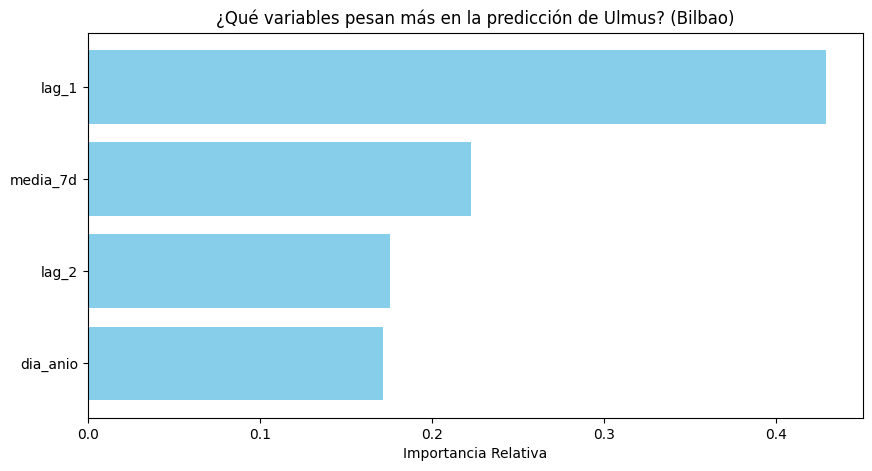

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

def graficar_importancia(ciudad, especie):
    # Cargar el modelo
    nombre_mod = f"C:\\Users\\wence\\OneDrive\\Escritorio\\Universidad\\openJdk-25\\TFG_Aitana\\modelos_entrenados\\modelo_{ciudad}_{especie.replace('/', '_')}.pkl"
    modelo = joblib.load(nombre_mod)
    
    # Nombres de las variables
    features = ['dia_anio', 'lag_1', 'lag_2', 'media_7d']
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)

    plt.figure(figsize=(10, 5))
    plt.title(f'¿Qué variables pesan más en la predicción de {especie}? ({ciudad})')
    plt.barh(range(len(indices)), importancias[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Importancia Relativa')
    plt.show()

# Ejemplo para ver qué influye más en las Gramíneas de Bilbao
graficar_importancia('Bilbao', 'Ulmus')

In [6]:
import joblib
import pandas as pd
from datetime import timedelta
import os
umbrales_polen = {
    # Muy Alergénicos
    'Poaceae': {'bajo': 25, 'moderado': 50},
    'Olea': {'bajo': 50, 'moderado': 200},
    'Urticaceae': {'bajo': 15, 'moderado': 30},
    'Plantago': {'bajo': 25, 'moderado': 50},
    'Chenopo/Amarant': {'bajo': 25, 'moderado': 50},
    
    # Árboles con síntomas claros
    'Platanus': {'bajo': 50, 'moderado': 200},
    'Cupress/Taxaceae': {'bajo': 50, 'moderado': 200},
    'Betula': {'bajo': 30, 'moderado': 50},
    'Alnus': {'bajo': 30, 'moderado': 50},
    'Fraxinus': {'bajo': 50, 'moderado': 200},
    'Corylus': {'bajo': 30, 'moderado': 50},
    'Quercus': {'bajo': 50, 'moderado': 200},
    'Ulmus': {'bajo': 30, 'moderado': 50},
    'Populus': {'bajo': 50, 'moderado': 200},
    'Salix': {'bajo': 50, 'moderado': 200},
    'Castanea': {'bajo': 30, 'moderado': 50},
    'Ligustrum': {'bajo': 30, 'moderado': 50},
    
    # Especiales y otros con síntomas
    'Pinus': {'bajo': 50, 'moderado': 200},
    'Alternaria': {'bajo': 15, 'moderado': 30}
}
def calcular_nivel(especie, cantidad):
    # Si el valor es NaN o nulo, avisamos al usuario
    if pd.isna(cantidad) or cantidad == "nan":
        return "Sin datos disponibles ⚪"
    
    # Convertimos a número por si acaso viene como texto
    cantidad = float(cantidad)
    
    if cantidad == 0:
        return "Nulo o inapreciable 🟢"
    
    limites = umbrales_polen.get(especie, {'bajo': 30, 'moderado': 100})
    print (limites['bajo'], limites['moderado'])
    
    if cantidad < limites['bajo']:
        return "Bajo 🟢"
    elif cantidad < limites['moderado']:
        return "Moderado 🟡"
    else:
        return "Alto 🔴"

def predecir_y_clasificar(ciudad, especie, fecha_objetivo):
    """
    Carga el modelo de la IA y predice el nivel de polen para una fecha específica.
    """
    # 1. Busca el modelo .pkl correspondiente
    nombre_modelo = f"modelo_{ciudad}_{especie.replace('/', '_')}.pkl"
    ruta_modelo = os.path.join('C:\\Users\\wence\\OneDrive\\Escritorio\\Universidad\\openJdk-25\\TFG_Aitana\\modelos_entrenados', nombre_modelo)
    
    if not os.path.exists(ruta_modelo):
        return f"Error: No existe modelo entrenado para {especie} en {ciudad}", 0
    
    modelo = joblib.load(ruta_modelo) #carga el modelo guardado (el pkl)
    
    # 2. Filtra los miles de datos para quedarse solo con los de la ciudad elegida
    df_hist = pd.read_csv(os.path.join('C:\\Users\\wence\\OneDrive\\Escritorio\\Universidad\\openJdk-25\\TFG_Aitana\\datos_procesados', 'polen_euskadi_final.csv'), sep=';')
    df_hist['Fecha'] = pd.to_datetime(df_hist['Fecha'])
    df_reciente = df_hist[df_hist['Ciudad'] == ciudad].sort_values('Fecha') #ordenados del más antiguo al más nuevo.
    
    # Extrae los ingredientes para la IA, l valor de ayer (-1), el de anteayer (-2) y el promedio de la última semana.
    ultimo_valor = df_reciente[especie].iloc[-1]
    penultimo_valor = df_reciente[especie].iloc[-2]
    media_7d = df_reciente[especie].tail(7).mean()
    
    # 3. Preparar la entrada para la IA
    # La IA espera: [dia_año, lag_1, lag_2, media_7d]
    X_input = pd.DataFrame([{
        'dia_año': fecha_objetivo.dayofyear,
        'lag_1': ultimo_valor,
        'lag_2': penultimo_valor,
        'media_7d': media_7d
    }])
    
    # 4. Ejecutar la Predicción
    prediccion_valor = modelo.predict(X_input)[0]
    prediccion_valor = max(0, prediccion_valor) # Evitar valores negativos
    
    # 5. Clasificar el nivel usando tu función calcular_nivel (la que ya tenías)
    # Reutilizamos tu lógica de umbrales
    nivel_texto = calcular_nivel(especie, prediccion_valor)
    
    return nivel_texto, round(prediccion_valor, 2)

# --- PRUEBA PARA TU APP (PREDICCIÓN DE MAÑANA) ---
ciudad_app = "Bilbao"
especie_app = "Poaceae" # Gramíneas
mañana = pd.Timestamp.now() + timedelta(days=1)

estado_predicho, cantidad_predicha = predecir_y_clasificar(ciudad_app, especie_app, mañana)

print(f"🔮 PREDICCIÓN PARA TU APP ({mañana.date()}):")
print(f"Ciudad: {ciudad_app} | Especie: {especie_app}")
print(f"Cantidad estimada: {cantidad_predicha} granos/m3")
print(f"Riesgo previsto: {estado_predicho}")

25 50
🔮 PREDICCIÓN PARA TU APP (2026-03-13):
Ciudad: Bilbao | Especie: Poaceae
Cantidad estimada: 0.66 granos/m3
Riesgo previsto: Bajo 🟢
